# Monday, March 2nd, 2026

Last week, we looked at plotting using `matplotlib.pyplot` and started talking about the `numpy` package.

## [Project 2: Pythagorean triples](https://jllottes.github.io/Projects/pythagorean_triples/pythagorean_triples.html)

The second project deals with exploring triples of integers known as *Pythagorean triples* (see [project page](https://jllottes.github.io/Projects/pythagorean_triples/pythagorean_triples.html) for details). We already have all of the Python tools necessary to find and explore these triples, and we will continue discussing using Matplotlib to visualize them.

One of the first tasks that we will need to tackle is to identify when we have a Pythagorean triple. To do so, it will be helpful if we can identify whether or not a given integer $n$ is a perfect square. That is, we want to determine if $n = m^2$ for some integer $m$.

**Exercise:** Write a function `is_square` that takes in an integer `n` and returns `True` if `n` is a perfect square and `False` otherwise.

It may be helpful to use the `round` function.

In [8]:
from math import sqrt

In [9]:
def is_square(n):
    sqrt_n = sqrt(n)
    if sqrt_n == round(sqrt_n):
        return True
    return False

In [ ]:
def is_square(n):
    sqrt_n = sqrt(n)
    if n == round(sqrt_n)**2:
        return True
    return False

In [12]:
for n in range(101):
    if is_square(n):
        print(n, 'is square')

0 is square
1 is square
4 is square
9 is square
16 is square
25 is square
36 is square
49 is square
64 is square
81 is square
100 is square


**Exercise:** Write a function `is_ptriple` that takes in a triple of integers $(a,b,c)$ and returns `True` if the triple is a Pythagorean triple, and `False` otherwise.

In [13]:
def is_ptriple(a,b,c):
    if a**2 + b**2 == c**2:
        return True
    else:
        return False

In [16]:
is_ptriple(5,12,14)

False

**Exercise:** Write a function `is_pdouble` that takes in a double of integers $(a,b)$ and returns `True` if the double is a Pythagorean double, and `False` otherwise.

**Exercise:** Generate all Pythagorean triples with $1 \leq a,b \leq 50$ and create a figure that plots $a$ versus $b$. You will need to generate separate lists that contain just the $a$ parts and just the $b$ parts of each Pythagorean triple.

## NumPy

The NumPy (*Num*erical *Py*thon) module contains many useful tools for numerical calculations in Python. We typically import the module and assign the name `np`.

In [31]:
import numpy as np

The basic building blocks in NumPy are *arrays*, which in many ways behave like lists. We can use the `np.array` function to convert a list to an array.

In [32]:
my_array = np.array([0,1,2,3,4,5,6])
my_array

array([0, 1, 2, 3, 4, 5, 6])

Just like with lists, we can acccess elements of an array by index using square brackets:

In [35]:
print(my_array[0])

0


In [36]:
print(my_array[5])

5


In [37]:
print(my_array[-2])

5


We can also use slicing to access parts of an array, similar to lists.

In [38]:
print(my_array[:3])

[0 1 2]


In [39]:
print(my_array[::2])

[0 2 4 6]


Unlike lists, NumPy arrays are built to perform arithmetic operations on an element-by-element basis. For example, compare what happens when we multiply a list by an integer and what happens when we multiply an array by an integer.

In [40]:
my_list = [0,1,2,3,4,5,6]
print(my_list*2)

[0, 1, 2, 3, 4, 5, 6, 0, 1, 2, 3, 4, 5, 6]


In [41]:
print(my_array*2)

[ 0  2  4  6  8 10 12]


In a similar way:

 - Adding/subtracting/multiplying/dividing an array by an integer/float adds/subtracts/multiplies/divides each element by the integer/float.
 - Exponentiating/modular dividing an array by an integer/float is performed on each element.
 - If we have two arrays of the same shape, we can add/subtract/multiply/divide/exponentiate/modular divide one by the other. The operation will be performed element-by-element (that is, the first elements from each array will be added/subtracted/multiplied/etc., the second elements from each array will be...).

In [43]:
my_array / 3.5

array([0.        , 0.28571429, 0.57142857, 0.85714286, 1.14285714,
       1.42857143, 1.71428571])

In [44]:
2**my_array

array([ 1,  2,  4,  8, 16, 32, 64])

In [45]:
my_array**3

array([  0,   1,   8,  27,  64, 125, 216])

In [46]:
my_array1 = np.array([1,2,3])
my_array2 = np.array([4,5,6])

In [47]:
my_array1 + my_array2

array([5, 7, 9])

In [48]:
my_array1 ** my_array2

array([  1,  32, 729])

Let's return to the earlier exercise of plotting $y(t)$ using a densely-packed list (or array) of . The `np.linspace` function can be used to easliy generate an array of evenly spaced points over some interval. The basic syntax

> `np.linspace(a,b,N)` 

generates an array of $N$ evenly spaced points over the interval $[a, b]$.

In [ ]:
#help(np.linspace)

In [50]:
np.linspace(0,1,11)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

**Exercise:** Use NumPy and `plt.plot` to plot the previously described trajectories of objects in freefall on Earth and Mars.

In [53]:
def y(t, y0, v0=0, g=-9.8):
    return (g/2)*(t**2) + v0*t + y0

In [61]:
t = np.linspace(0,16,1000)

y_earth = y(t, 1000)
y_mars = y(t,1000,g=-3.71)

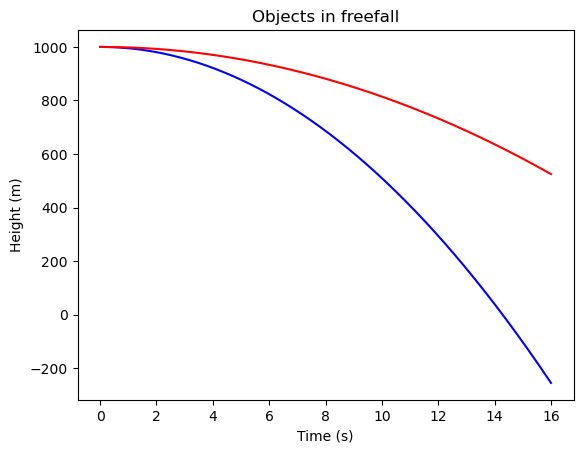

In [62]:
plt.plot(t,y_earth, 'b', label='Earth')
plt.plot(t,y_mars, 'r', label='Mars')

plt.title('Objects in freefall')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.show()

## Python loops versus NumPy

Python is a relatively easy language to code with (in comparison to C/C++, for example). On the other hand, it is a somewhat slow language. For example, Python is much slower to complete a `for` loop iteration than C/C++. The backbone of NumpPy is written in C/C++, which comes with speed advantages. The module essentially gives us the best of both worlds: the ease of use of Python with the speed of C/C++.

Let's compare how long it takes to generate one million equally spaced $x$-values over the interval $[0,2\pi]$ and compute both $y=\sin(x)$ and $y=\cos(x)$ using:
 - `for` loops to construct the lists of $x$- and $y$-values.
 - list comprehensions to construct the lists of $x$- and $y$-values.
 - `np.linspace`, `np.sin`, and `np.cos` to generate the arrays of $x$- and $y$-values.

Reminder: We can use the `time` function from the `time` module to time our code.

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import time
from math import pi, sin, cos

a = 0      # Left-end of the x-interval
b = 2*pi   # Right-end of the x-interval
N = 10**6   # Number of sub-intervals to divide (a,b) into

Recall, last week we discussed how to divide an interval $[a,b]$ into $N$ equally spaced sub-intervals with endpoints $x_0, x_1, x_2, \dots, x_N$, where
$$x_i = a + i\Delta x \qquad \text{for} \qquad i = 0, 1, ..., N, \qquad \text{with} \qquad \Delta x = \frac{b-a}{N}.$$

Using only `for` loops (no list comprehension):

In [67]:
t0 = time.time()

dx = (b-a)/N

x_list = []
sin_x_list = []
cos_x_list = []

for i in range(N+1):
    x = a + i*dx
    x_list.append(x)
    sin_x_list.append(sin(x))
    cos_x_list.append(cos(x))

t1 = time.time()
print(t1-t0, 'seconds using for loops')

2.563274621963501 seconds using for loops


Using list comprehension:

In [68]:
t0 = time.time()

dx = (b-a)/N

x_list = [ a + i*dx for i in range(N+1) ]
sin_x_list = [ sin(x) for x in x_list ]
cos_x_list = [ cos(x) for x in x_list ]

t1 = time.time()
print(t1-t0, 'seconds using list comprehensions')

2.325269937515259 seconds using list comprehensions


Using NumPy:

In [70]:
t0 = time.time()

x = np.linspace(a,b,N+1)
sin_x = np.sin(x)
cos_x = np.cos(x)

t1 = time.time()
print(t1-t0, 'seconds using NumPy')

0.1264023780822754 seconds using NumPy


## Generating Numpy arrays

We've already seen how we can convert lists to arrays and how we can use the `np.linspace` function to create arrays. There are many other ways to build arrays. For example:
 - `np.zeros` can generate arrays full of `0`s.
 - `np.ones` can generate arrays full of `1`s.
 - `np.arange` works just like the normal `range` function, except that it returns an array instead.

In [71]:
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [72]:
np.ones(5)

array([1., 1., 1., 1., 1.])

In [73]:
np.arange(8)

array([0, 1, 2, 3, 4, 5, 6, 7])

Note: the `np.zeros` function and `np.ones` function produce arrays filled with floats, while the `np.arange` function returns an array full of integers.

In general, NumPy arrays can only be filled with one datatype (unlike lists which can mix-and-match). We can check what datatype an array holds using the `.dtype` attribute:

In [74]:
np.zeros(10).dtype

dtype('float64')

In [75]:
np.arange(5).dtype

dtype('int64')

We can change the datatype when defining arrays using `np.zeros` or `np.ones` by using the `dtype` keyword argument:

In [76]:
0 * np.arange(5)

array([0, 0, 0, 0, 0])

In [79]:
np.zeros(10, dtype=int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [80]:
np.ones(5, dtype=bool)

array([ True,  True,  True,  True,  True])

We can also convert an existing array to a new datatype using the `.astype` method:

In [82]:
np.zeros(10).astype(bool)

array([False, False, False, False, False, False, False, False, False,
       False])

Note: when converting to a Boolean data type, any non-zero integer/float is considered `True`. Only `0` is considered `False`.

## Slicing with NumPy

Just like with lists, we use slicing to access portions of a NumPy array. Consider the following experiment.

First, we define a list and an array, each containing the integers `0`, ..., `19`.

In [83]:
N = 20

my_list = [i for i in range(N)]
my_array = np.arange(N)

In [84]:
print(my_list)
print(my_array)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


Now, let's take slices of the list and array that starts at index `1` and takes every other element.

In [85]:
list_slice = my_list[1::2]
array_slice = my_array[1::2]

Before continuing, let's see what the slices look like.

In [86]:
print(list_slice)
print(array_slice)

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
[ 1  3  5  7  9 11 13 15 17 19]


*Small note: lists and NumPy arrays are displayed slighty differently when printed. Namely, when printing NumPy arrays, the commas separating the elements are omitted.*

What happens if we modify these slices? For example, let's change the first entry of the list slice to be `99`.

In [87]:
list_slice[0] = 99
print('Modified slice:')
print(list_slice)
print('Original list:')
print(my_list)

Modified slice:
[99, 3, 5, 7, 9, 11, 13, 15, 17, 19]
Original list:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


We can see that, with the list, the changes to the slice **do not** propogate back to the original list. What happens if we perform the same experiment with the NumPy array?

In [88]:
array_slice[0] = 99
print('Modified slice:')
print(array_slice)
print('Original array:')
print(my_array)

Modified slice:
[99  3  5  7  9 11 13 15 17 19]
Original array:
[ 0 99  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


With the NumPy array, the changes to the slice **do** propogate back to the original list.

What's happening here? 
 - When slicing a list, we obtain a new list object that is unattached to the original list. Changes to one do not affect the other.
 - When slicing an array, we obtain a "view" of the original array. Changes to the slice affect the original array, and vice-versa.

If we want to obtain a slice of an array that is unattached to the original array, we can use the `.copy` method to sever the connection.